In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
df = pd.read_csv("data/flat.csv", sep='\t', index_col='n')
print("Размер выборки: ", df.shape)
df.head()

Размер выборки:  (2040, 10)


,price,totsp,livesp,kitsp,dist,metrdist,walk,brick,floor,code
n,,,,,,,,,,
1,81,58,40,6.0,12.5,7,1,1,1,3
2,75,44,28,6.0,13.5,7,1,0,1,6
3,128,70,42,6.0,14.5,3,1,1,1,3
4,95,61,37,6.0,13.5,7,1,0,1,1
5,330,104,60,11.0,10.5,7,0,1,1,3


**Описание переменных:**

* `n` — номер квартиры по порядку
* `price` — цена квартиры в $1000
* `totsp` — общая площадь квартиры, кв.м.
* `livesp` — жилая площадь квартиры, кв.м.
* `kitsp` — площадь кухни, кв.м.
* `dist` — расстояние от центра в км.
* `metrdist` — расстояние до метро в минутах
* `walk` — 1 — пешком от метро, 0 — на транспорте
* `brick` — 1 — кирпичный, монолит ж/б, 0 — другой
* `floor` — 1 — этаж кроме первого и последнего, 0 — иначе
* `code` — число от 1 до 8, при помощи которого мы группируем наблюдения по подвыборкам:

1. Наблюдения сгруппированы на севере, вокруг Калужско-Рижской линии метрополитена
2. Север, вокруг Серпуховско-Тимирязевской линии метрополитена
3. Северо-запад, вокруг Замоскворецкой линии метрополитена
4. Северо-запад, вокруг Таганско-Краснопресненской линии метрополитена
5. Юго-восток, вокруг Люблинской линии метрополитена
6. Юго-восток, вокруг Таганско-Краснопресненской линии метрополитена
7. Восток, вокруг Калиниской линии метрополитена
8. Восток, вокруг Арбатско-Покровской линии метрополитена


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2040 entries, 1 to 2040
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   price     2040 non-null   int64  
 1   totsp     2040 non-null   int64  
 2   livesp    2040 non-null   int64  
 3   kitsp     2040 non-null   float64
 4   dist      2040 non-null   float64
 5   metrdist  2040 non-null   int64  
 6   walk      2040 non-null   int64  
 7   brick     2040 non-null   int64  
 8   floor     2040 non-null   int64  
 9   code      2040 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 175.3 KB


In [5]:
df.isnull().sum()

price       0
totsp       0
livesp      0
kitsp       0
dist        0
metrdist    0
walk        0
brick       0
floor       0
code        0
dtype: int64

<Axes: >

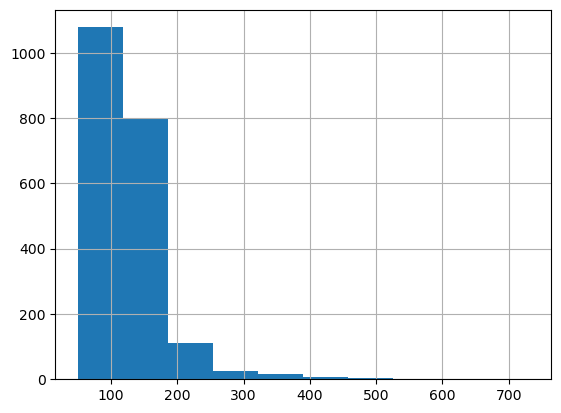

In [6]:
df['price'].hist()

Распределение очень скошено налево(такие распределения называют log-нормальными), его нужно прологорифмировать.
У распределения цен есть проблема - очень длинный хвост. В выборке встречаются квартиры с довольно большой стоимостью. Такие наблюдения называются выбросами. С ними нужно бороться, иначе наша модель подстроится под них. Давайте сгладим распределение цен, прологарифмировав его. Так довольно часто поступают с целевой переменной.

<Axes: >

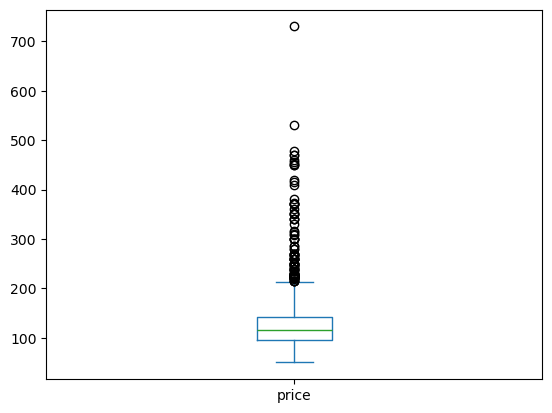

In [7]:
df.price.plot.box()

In [8]:
df['price'] = np.log(df['price'])
df.price

n
1       4.394449
2       4.317488
3       4.852030
4       4.553877
5       5.799093
          ...   
2036    4.700480
2037    4.553877
2038    4.553877
2039    4.859812
2040    4.634729
Name: price, Length: 2040, dtype: float64

<Axes: >

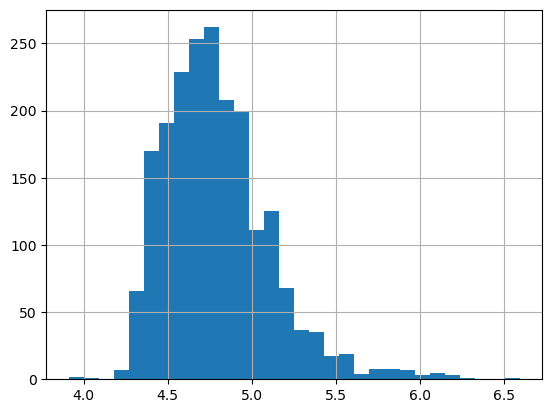

In [9]:
df.price.hist(bins=30)

<Axes: >

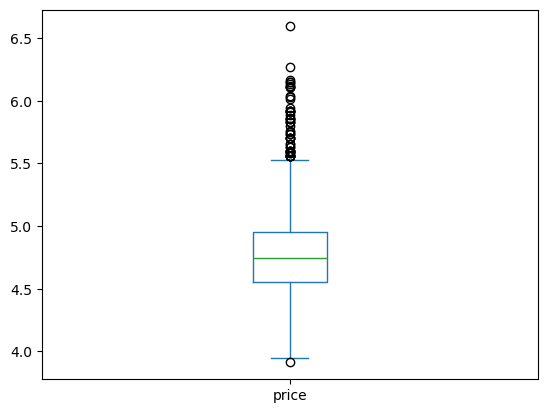

In [10]:
df.price.plot.box()

array([[<Axes: title={'center': 'totsp'}>,
        <Axes: title={'center': 'livesp'}>,
        <Axes: title={'center': 'kitsp'}>],
       [<Axes: title={'center': 'dist'}>,
        <Axes: title={'center': 'metrdist'}>,
        <Axes: title={'center': 'walk'}>],
       [<Axes: title={'center': 'brick'}>,
        <Axes: title={'center': 'floor'}>,
        <Axes: title={'center': 'code'}>]], dtype=object)

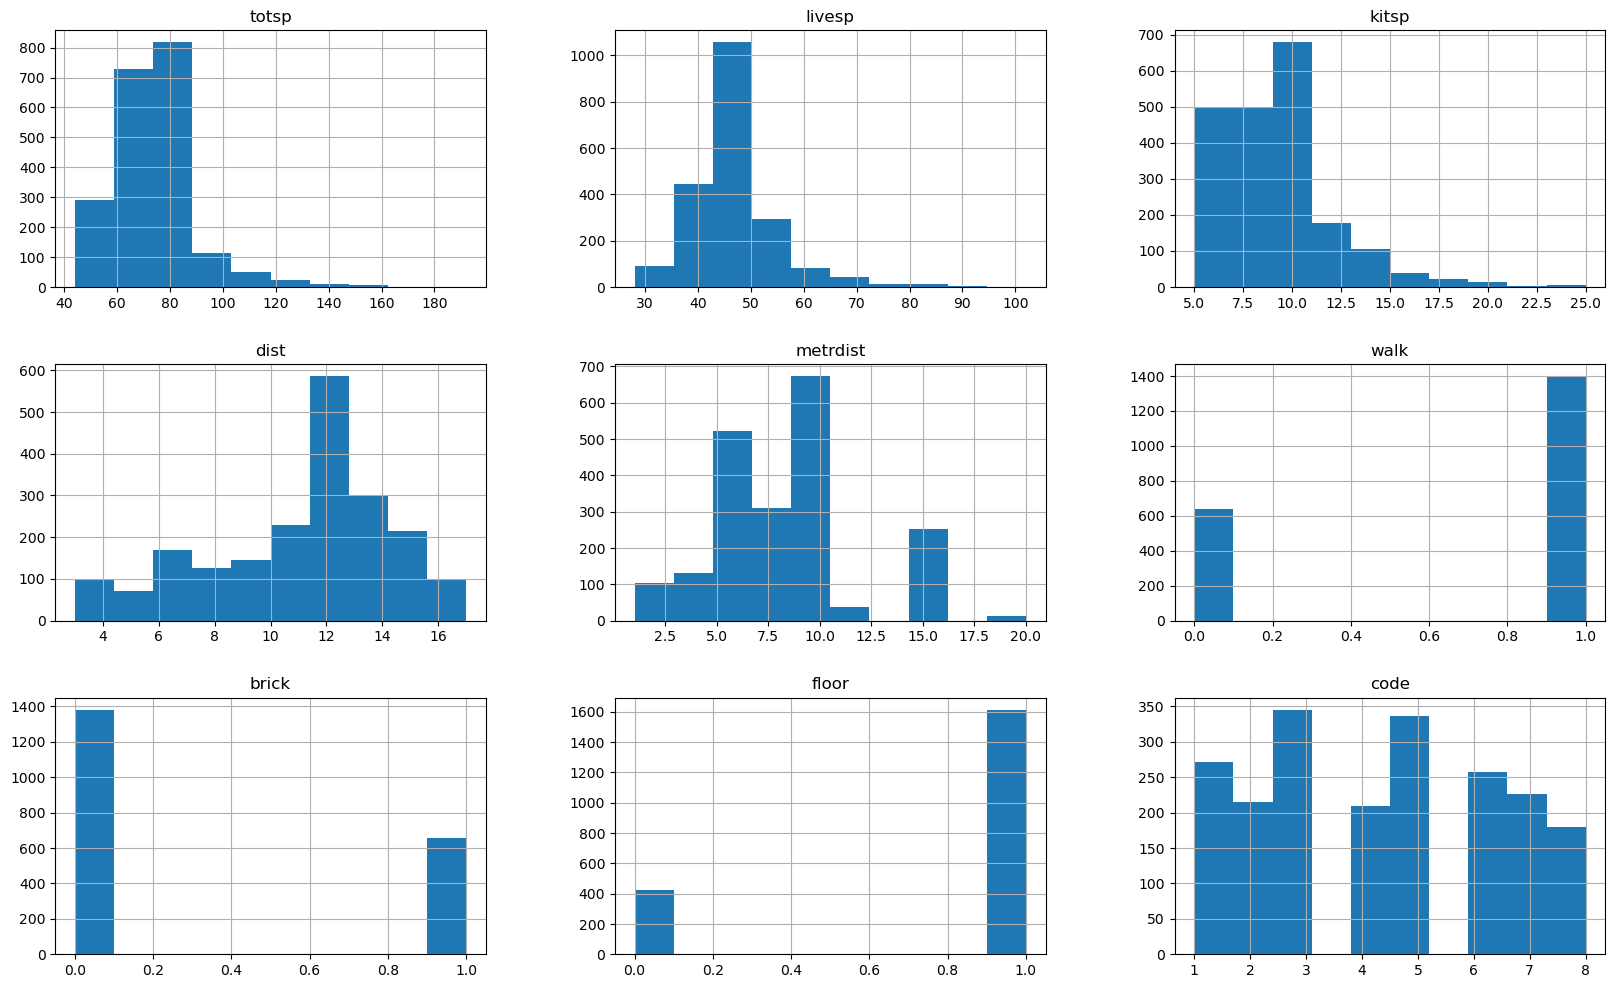

In [11]:
df.drop('price', axis=1).hist(figsize=(20,12))

<Axes: >

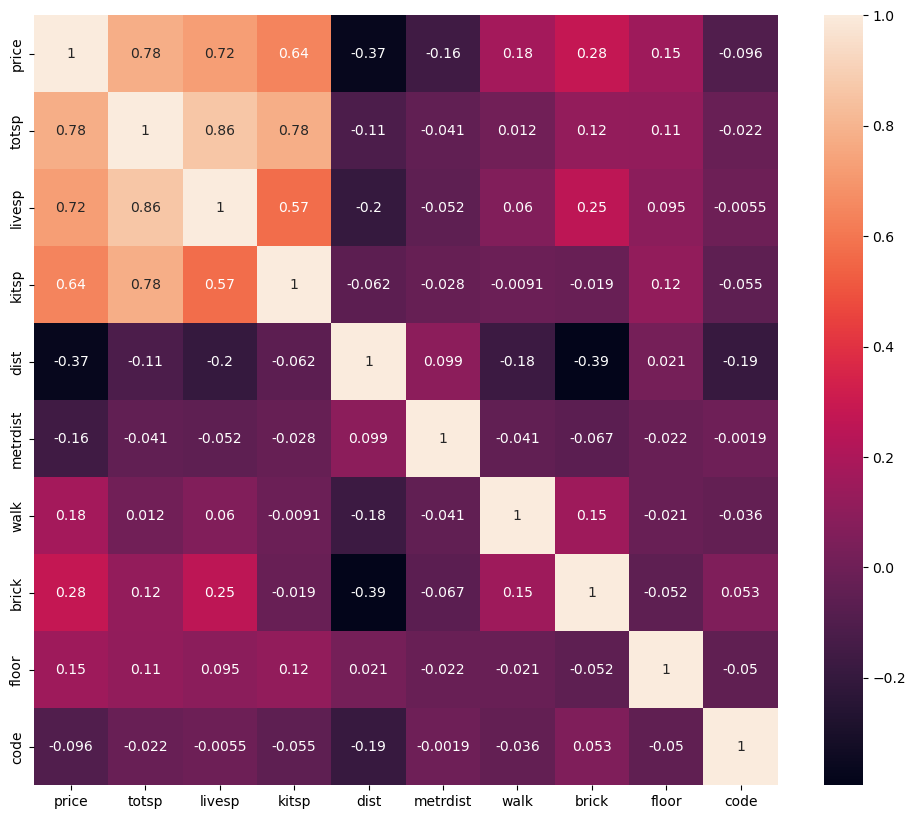

In [12]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True)

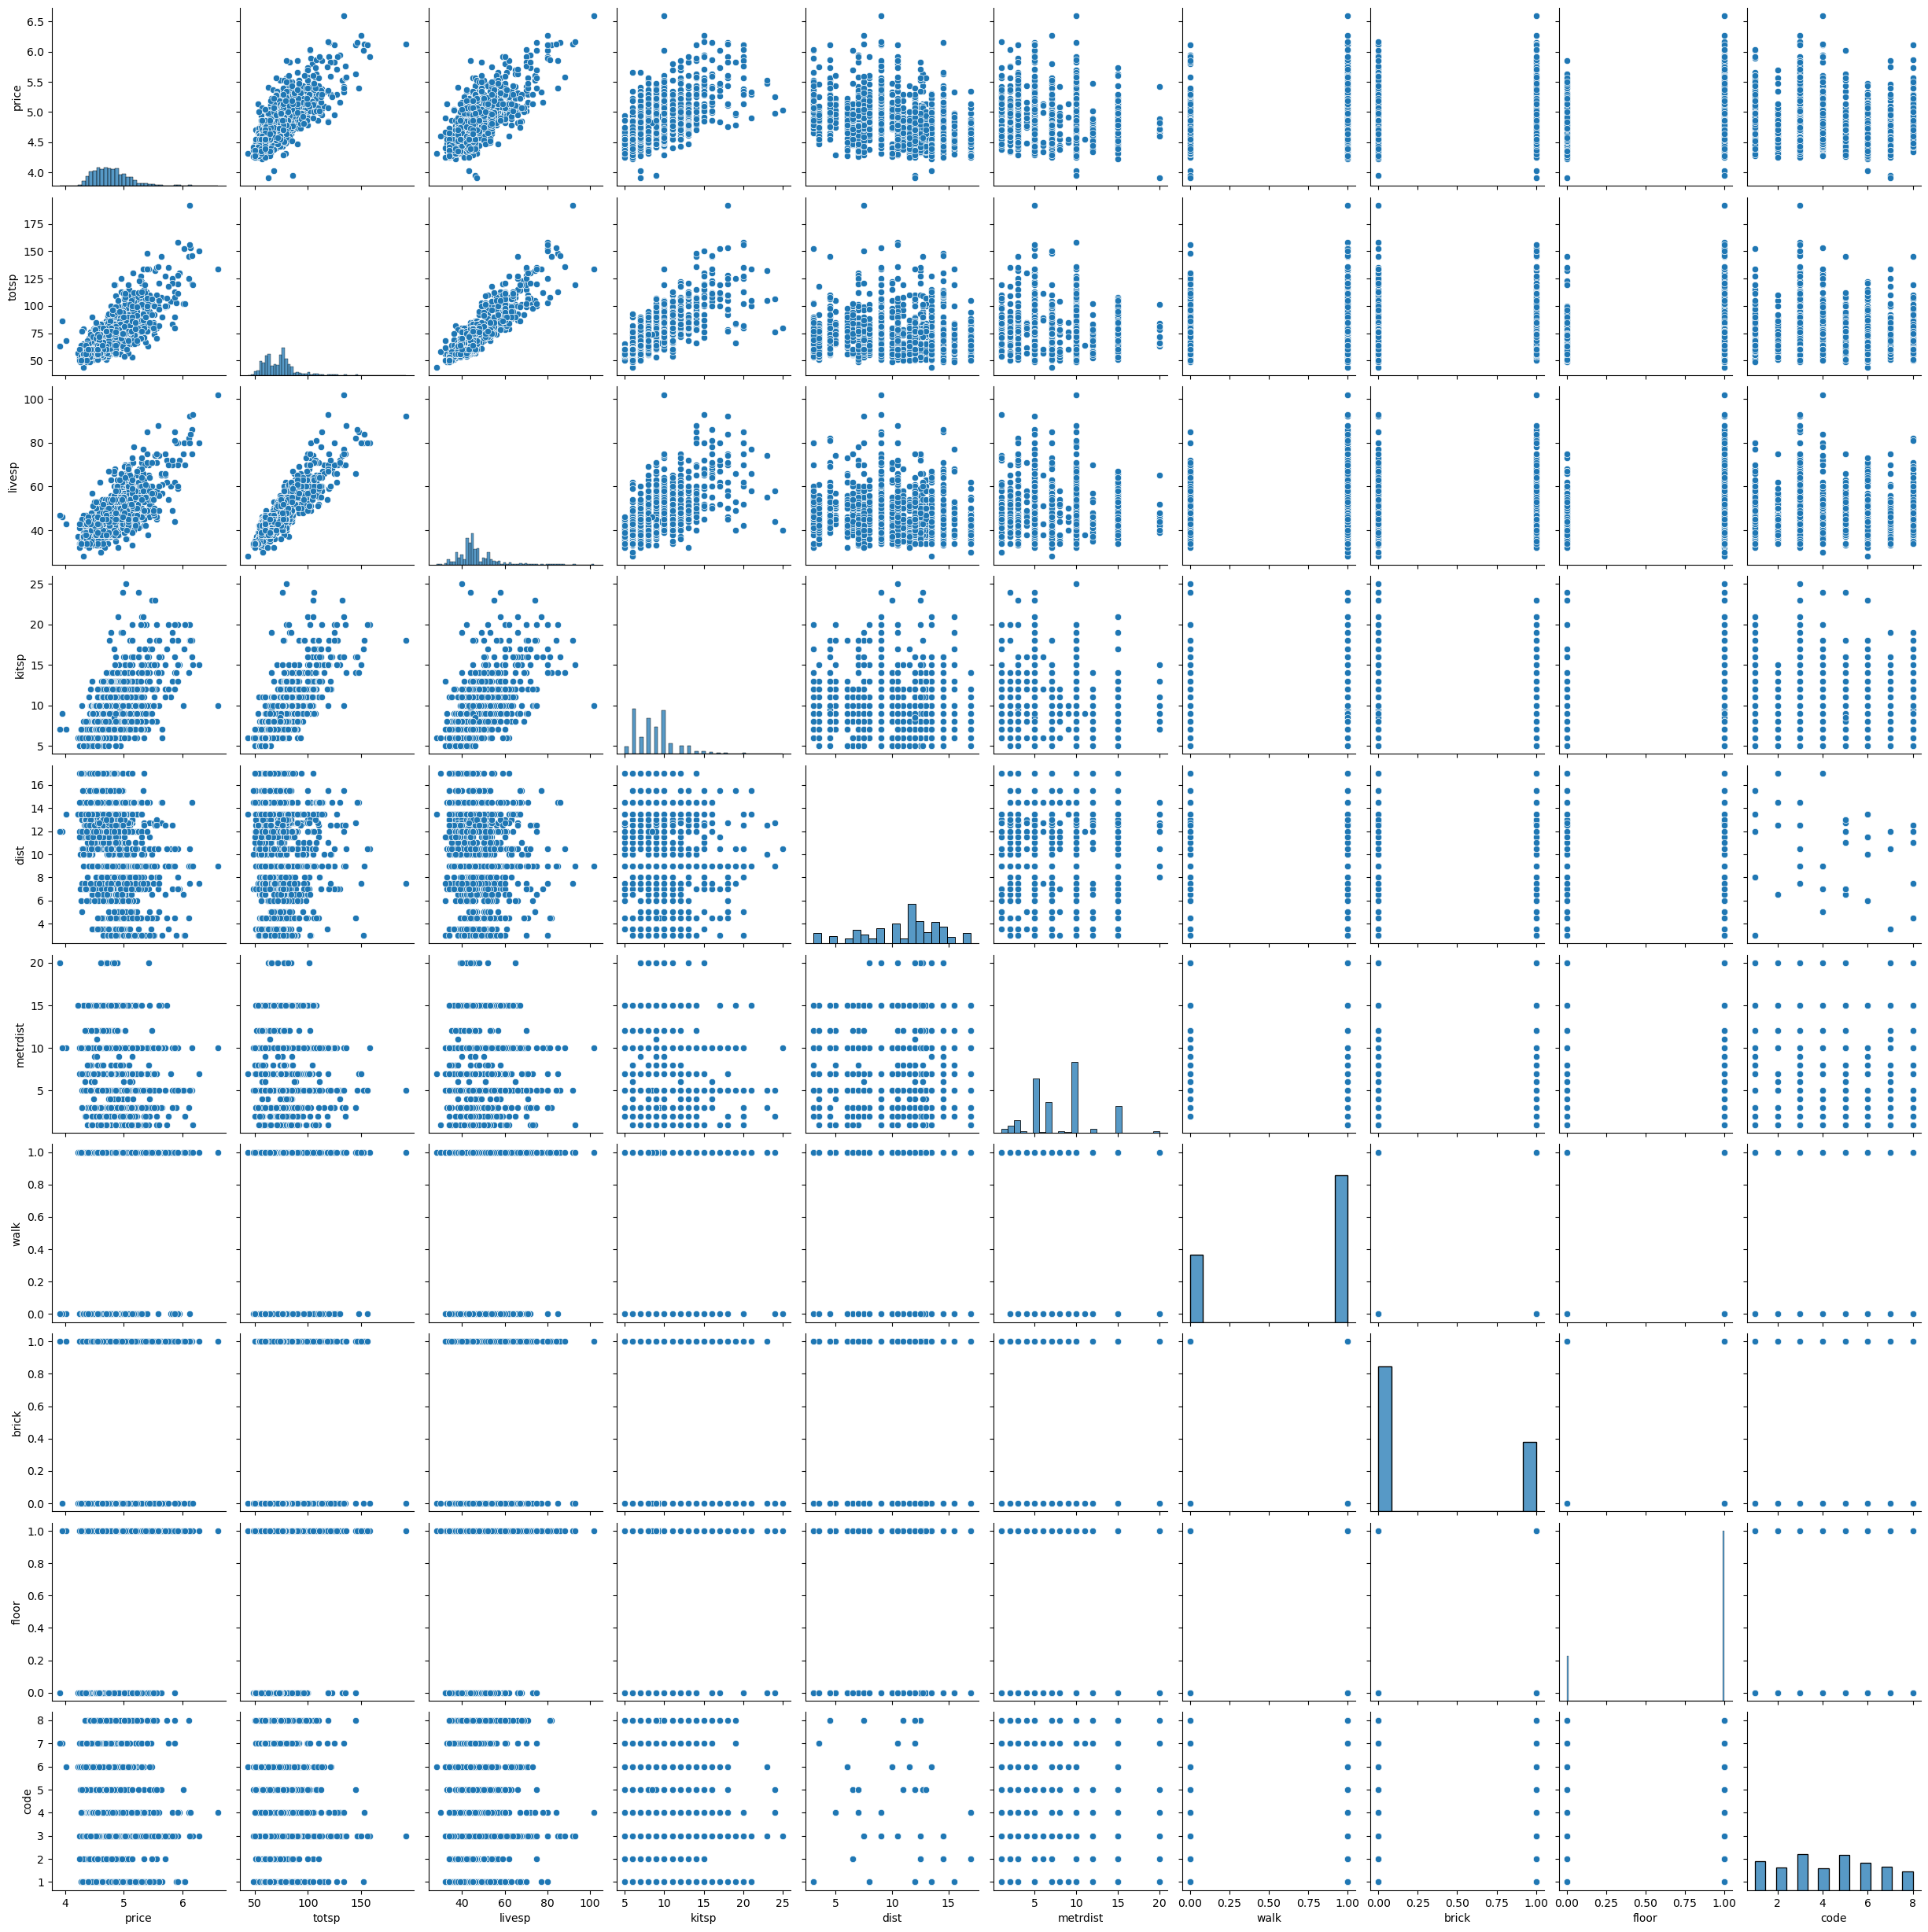

In [51]:
sns.pairplot(df)

In [13]:
df.head()

,price,totsp,livesp,kitsp,dist,metrdist,walk,brick,floor,code
n,,,,,,,,,,
1,4.394449,58,40,6.0,12.5,7,1,1,1,3
2,4.317488,44,28,6.0,13.5,7,1,0,1,6
3,4.852030,70,42,6.0,14.5,3,1,1,1,3
4,4.553877,61,37,6.0,13.5,7,1,0,1,1
5,5.799093,104,60,11.0,10.5,7,0,1,1,3


In [14]:
df.code

n
1       3
2       6
3       3
4       1
5       3
       ..
2036    5
2037    4
2038    7
2039    3
2040    1
Name: code, Length: 2040, dtype: int64

# Предобработка данных (OneHotEncoding)

In [15]:
#создание OHE для категориальной переменной
df_categor = pd.get_dummies(df['code'], drop_first=True, prefix='code', dtype=int)

df = pd.concat([df.drop('code', axis=1), df_categor], axis=1)
df.head()

,price,totsp,livesp,kitsp,dist,metrdist,walk,brick,floor,code_2,code_3,code_4,code_5,code_6,code_7,code_8
n,,,,,,,,,,,,,,,,
1,4.394449,58,40,6.0,12.5,7,1,1,1,0,1,0,0,0,0,0
2,4.317488,44,28,6.0,13.5,7,1,0,1,0,0,0,0,1,0,0
3,4.852030,70,42,6.0,14.5,3,1,1,1,0,1,0,0,0,0,0
4,4.553877,61,37,6.0,13.5,7,1,0,1,0,0,0,0,0,0,0
5,5.799093,104,60,11.0,10.5,7,0,1,1,0,1,0,0,0,0,0


In [16]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, test_size=0.3)

Последний предобрабатывательский штрих это скалирование (стандартизация непрерывных переменных). Давайте вспомним зачем его делают. Обычно, когда обучают модель, хотят минимизировать ошибку, которую она допускает. Чаще всего эту функцию минимизируют численно. Если переменные измерены в разных шкалах (что-то в тоннах, что-то в годах и тд), алгоритм может при обучении заблудиться. Хорошо бы направить его и подтолкнуть в нужном направлении. Таким толчком является стандартизация переменных.

Из каждой переменной вычетают среднее и делят на стандартное отклонение. Это очищает переменные от своих уникальных шкал и упрощает путь алгоритма к оптимальной точке. Обычно стандартное отклонение и среднее для скалирования оценивают на обучающей выборке. К тестовой применяют уже оценённый результат. Это позволяет не подглядывать в тестовую часть и не улучшать за счёт этого подглядывания прогнозы. Подглядывать - нечестно!


In [17]:
df.head()

,price,totsp,livesp,kitsp,dist,metrdist,walk,brick,floor,code_2,code_3,code_4,code_5,code_6,code_7,code_8
n,,,,,,,,,,,,,,,,
1,4.394449,58,40,6.0,12.5,7,1,1,1,0,1,0,0,0,0,0
2,4.317488,44,28,6.0,13.5,7,1,0,1,0,0,0,0,1,0,0
3,4.852030,70,42,6.0,14.5,3,1,1,1,0,1,0,0,0,0,0
4,4.553877,61,37,6.0,13.5,7,1,0,1,0,0,0,0,0,0,0
5,5.799093,104,60,11.0,10.5,7,0,1,1,0,1,0,0,0,0,0


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(df_train[['totsp', 'livesp', 'kitsp', 'dist', 'metrdist']])

,copy,True
,with_mean,True
,with_std,True


In [19]:
# Применение скаляровщика к train
df_train_scale = scaler.transform(df_train[['totsp', 'livesp', 'kitsp', 'dist', 'metrdist']])

# Применение скаляровщика к test
df_test_scale = scaler.transform(df_test[['totsp', 'livesp', 'kitsp', 'dist', 'metrdist']])

In [20]:
df_train[['totsp', 'livesp', 'kitsp', 'dist', 'metrdist']] = df_train_scale
df_test[['totsp', 'livesp', 'kitsp', 'dist', 'metrdist']] = df_test_scale

Все непрерывные перемнные теперь выглядят проскалироваными

In [21]:
df_train.head()

,price,totsp,livesp,kitsp,dist,metrdist,walk,brick,floor,code_2,code_3,code_4,code_5,code_6,code_7,code_8
n,,,,,,,,,,,,,,,,
532,4.700480,-0.193168,-0.788441,0.050293,0.731665,-0.833715,1,0,0,0,0,0,0,1,0,0
1053,4.442651,-0.844974,-1.038695,-1.035131,1.774932,-0.303877,1,0,0,1,0,0,0,0,0,0
239,4.912655,0.067554,-0.162805,0.412102,0.731665,-0.833715,0,0,1,0,0,0,0,0,0,0
1035,4.521789,-0.779793,-0.287932,-1.035131,0.433588,-0.833715,1,0,1,1,0,0,0,0,0,0
1399,4.543295,-0.649432,-0.913568,-0.311515,1.029741,-0.833715,0,0,1,1,0,0,0,0,0,0


In [22]:
print(df_train.shape)
print(df_test.shape)

(1428, 16)
(612, 16)


In [23]:
# вытаскиваем цены и параметры квартир по разным переменным

y_train = df_train.price
y_test = df_test.price

X_train = df_train.drop('price', axis=1).values
X_test = df_test.drop('price', axis=1).values

# 2. Константный прогноз

Шаг первый. Построим константный прогноз. Будем говорить, что стоимость любой квартиры равна среднему значению. Это самый глупый прогноз, который мы можем сделать. Мы будм сравнивать с ним прогнозы более сложных моделей.

In [25]:
y_mean = np.mean(y_train) # посчитали среднее
y_pred_naive = np.ones(len(y_test)) * y_mean # спрогнозировали им цену всех квартир в тестовой выборке 
y_pred_naive[:5]

array([4.78974257, 4.78974257, 4.78974257, 4.78974257, 4.78974257])